In [19]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df=pd.read_csv("C:\\Users\\HP\\Desktop\\FULLSTACK\\Project1\\HR_Employee_Attrition.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize=True))


(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


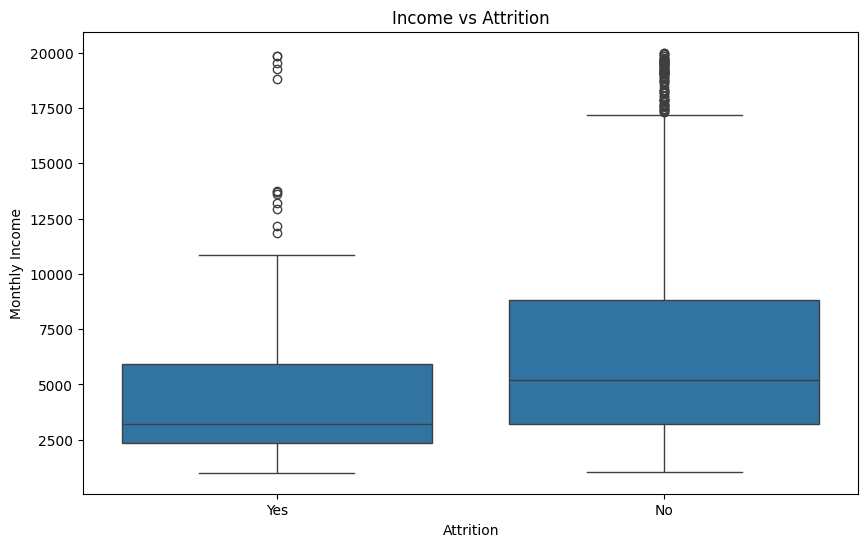

In [21]:
#Income vs Attrition
plt.figure(figsize=(10,6))
sns.boxplot(x="Attrition", y="MonthlyIncome",data=df)
plt.title("Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

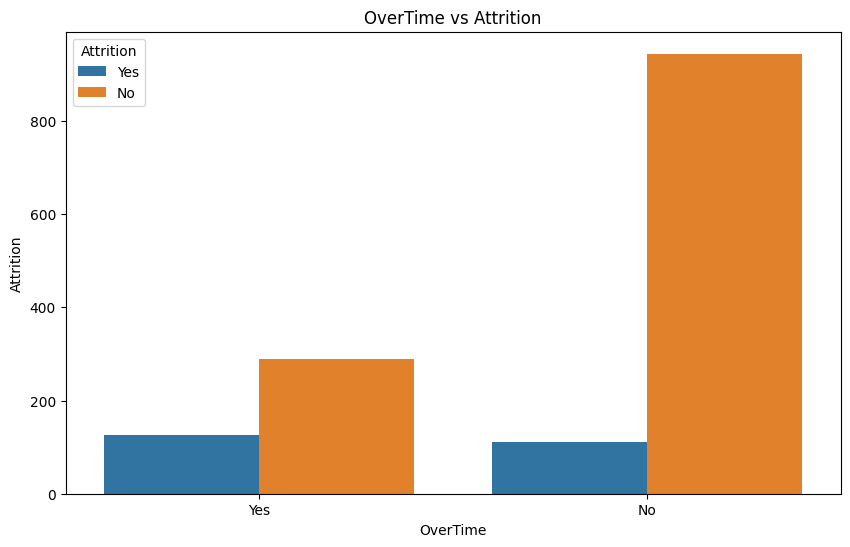

In [22]:
#OverTime vs Attrition
plt.figure(figsize=(10, 6))
sns.countplot(x = "OverTime", hue="Attrition", data=df,)
plt.title("OverTime vs Attrition")
plt.xlabel("OverTime")
plt.ylabel("Attrition")
plt.legend(title="Attrition")
plt.show()


In [23]:
#Drop irrelevant columns
df.drop(["EmployeeNumber","EmployeeCount","Over18","StandardHours"], axis=1,inplace=True)
encoder = {}
for col in df.select_dtypes(include=["object"]).columns:
    lb = LabelEncoder()
    df[col]=lb.fit_transform(df[col])
    encoder[col] = lb
    X=df.drop("Attrition",axis=1)
    y=df["Attrition"]
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.4,random_state=42)

model = RandomForestClassifier(**grid_search.best_params_,random_state=42)
model.fit(X,y)
#save the maodel
joblib.dump(model,"employee_attrition_model.pkl")
joblib.dump(encoder,"label_encoder.pkl")
joblib.dump(X.columns.to_list(), "feature_columns.pkl")

In [24]:
model = RandomForestClassifier(**grid_search.best_params_,random_state=42)
model.fit(X,y)
#save the maodel
joblib.dump(model,"employee_attrition_model.pkl")
joblib.dump(encoder,"label_encoder.pkl")
joblib.dump(X.columns.to_list(), "feature_columns.pkl")

['feature_columns.pkl']

In [25]:
rf=RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50,100],    
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5,scoring='f1')
grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [26]:
model = RandomForestClassifier(**grid_search.best_params_, random_state=42)
model.fit(X,y)
joblib.dump(model, "employee_attrition_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")
joblib.dump(X.columns, "feature_columns.pkl")

['feature_columns.pkl']

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       507
           1       0.81      0.16      0.27        81

    accuracy                           0.88       588
   macro avg       0.85      0.58      0.60       588
weighted avg       0.87      0.88      0.84       588

[[504   3]
 [ 68  13]]


Text(0, 0.5, 'Feature')

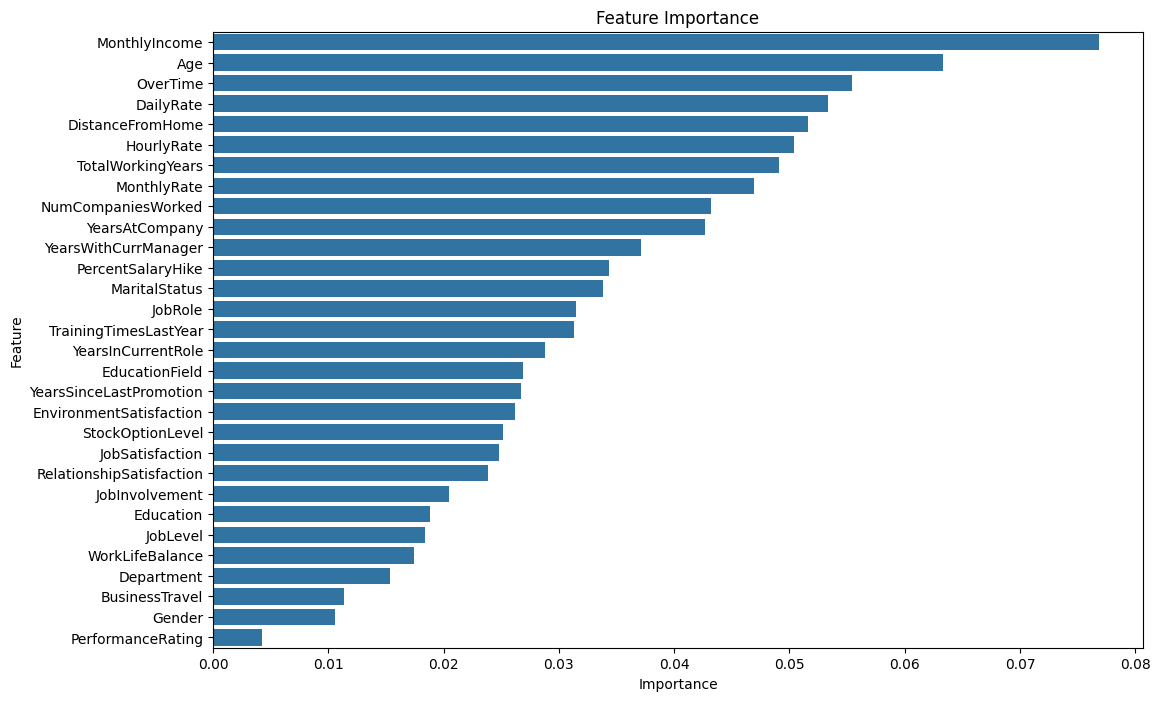

In [27]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test) 
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
